# MCDI504 · Machine Learning I
## Evaluación Formativa 4 · Avance del Proyecto — Fase 4
### Evaluación y validación de modelos de clasificación

**Propósito.** Evaluar comparativamente modelos supervisados aplicados al caso Titanic, documentar matriz de confusión y métricas de clasificación, y aplicar validación cruzada a una red neuronal con **una capa oculta**, manteniendo trazabilidad con las fases anteriores del proyecto.

La clase positiva se define como `survived = 1` (sobrevivió). Las métricas principales son accuracy, precision, recall y F1-score; ROC-AUC y Average Precision se incorporan como evidencia complementaria del resultado de aprendizaje.

## 0. Entorno, rutas y reproducibilidad

Se fija `random_state=42`, se localiza la raíz del repositorio y se inicializan exclusivamente las carpetas de evidencia de la evaluación formativa. El dataset se lee desde `Semana3/data/titanic.csv` para preservar continuidad con la fase previa. Las versiones del entorno quedan registradas en `Semana4/Formativa/outputs/`.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
POS_LABEL = 1
np.random.seed(RANDOM_STATE)


def localizar_raiz_repo(inicio: Path) -> Path:
    inicio = inicio.resolve()
    candidatos = [inicio, *inicio.parents]
    for candidato in candidatos:
        if (candidato/'Semana3'/'data'/'titanic.csv').exists() and (candidato/'Semana4').exists():
            return candidato
    # búsqueda controlada hacia abajo por si Jupyter se abrió desde una carpeta superior
    encontrados = []
    for p in inicio.glob('**/Semana3/data/titanic.csv'):
        candidato = p.parents[2]
        if (candidato/'Semana4').exists():
            encontrados.append(candidato.resolve())
    encontrados = sorted(set(encontrados))
    if len(encontrados) == 1:
        return encontrados[0]
    if len(encontrados) > 1:
        raise FileNotFoundError('Se localizaron múltiples repositorios candidatos. Abra el notebook desde el proyecto correcto.')
    raise FileNotFoundError('No fue posible localizar la raíz del repositorio.')

ROOT = localizar_raiz_repo(Path.cwd())
S3 = ROOT/'Semana3'
FORM = ROOT/'Semana4'/'Formativa'
OUT_DIR = FORM/'outputs'
FIG_DIR = FORM/'figures'
DATA_DIR = FORM/'data'
for d in [OUT_DIR, FIG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Se eliminan únicamente artefactos generados por ejecuciones anteriores de esta Formativa.
for p in OUT_DIR.iterdir():
    if p.is_file() and p.name != 'README.md':
        p.unlink()
for p in FIG_DIR.iterdir():
    if p.is_file() and p.name != 'README.md':
        p.unlink()

versiones = pd.DataFrame([
    {'Componente':'Python', 'Version':platform.python_version()},
    {'Componente':'NumPy', 'Version':np.__version__},
    {'Componente':'pandas', 'Version':pd.__version__},
    {'Componente':'scikit-learn', 'Version':sklearn.__version__},
    {'Componente':'Matplotlib', 'Version':plt.matplotlib.__version__},
])
versiones.to_csv(OUT_DIR/'00_versiones_entorno.csv', index=False)
display(versiones)
print('Raíz del repositorio:', ROOT)

,Componente,Version
0,Python,3.12.4
1,NumPy,1.26.4
2,pandas,2.2.2
3,scikit-learn,1.4.2
4,Matplotlib,3.8.4


Raíz del repositorio: C:\Users\juani\Downloads\formativa\mcdi504-machine-learning-1-main


## 1. Dataset, variable objetivo, clase objetivo y modelos considerados

El caso utiliza el dataset Titanic archivado en Semana 3. Se seleccionan las mismas siete variables predictoras usadas en la fase de clasificación previa: `pclass`, `age`, `sibsp`, `parch`, `fare`, `sex` y `embarked`. Se excluyen variables redundantes, derivadas o con alta ausencia, en particular `alive`, porque replica conceptualmente la variable objetivo.

La evaluación formativa considera cuatro líneas base supervisadas —KNN, árbol de decisión, SVM y Gaussian Naive Bayes— y las tres arquitecturas MLP registradas en Semana 3. La validación cruzada exigida por la actividad se aplica específicamente al **MLP de una capa oculta**.

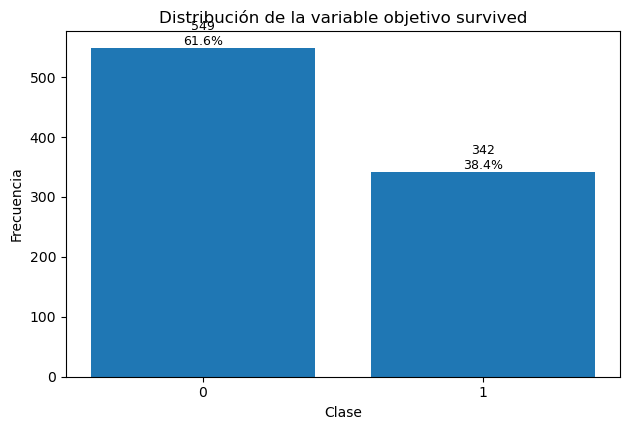

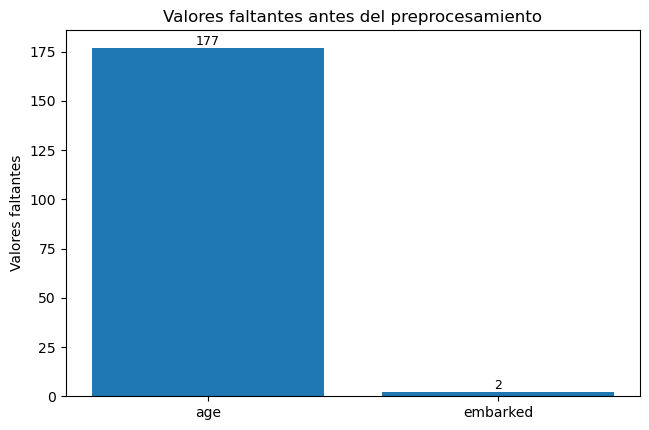

,Elemento,Valor
0,Observaciones,891
1,Columnas_originales,15
2,Predictores_seleccionados,7
3,Variable_objetivo,survived
4,Clase_positiva,1 = sobrevivió
5,SHA256_dataset,81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86...


,Clase,Frecuencia,Porcentaje
0,0,549,61.616162
1,1,342,38.383838


,Variable,Valores_faltantes
0,pclass,0
1,age,177
2,sibsp,0
3,parch,0
4,fare,0
5,sex,0
6,embarked,2
7,survived,0


,Modelo,Configuracion
0,KNN,n_neighbors=5; metric=minkowski; p=2; escalami...
1,Árbol de decisión,criterion=gini; max_depth=5; random_state=42
2,SVM,kernel=rbf; C=1; escalamiento numérico
3,Naive Bayes,GaussianNB
4,MLP 1 capa oculta,"hidden_layer_sizes=(100,); parámetros MLP here..."
5,MLP 2 capas ocultas,"hidden_layer_sizes=(100, 50); parámetros MLP h..."
6,MLP 3 capas ocultas,"hidden_layer_sizes=(100, 50, 25); parámetros M..."


In [2]:
DATA_PATH = S3/'data'/'titanic.csv'
FICHA_MLP_PATH = S3/'outputs'/'22_clf_fichas_tecnicas_mlp.csv'
METRICAS_MLP_S3_PATH = S3/'outputs'/'23_clf_metricas_mlp.csv'

TARGET = 'survived'
NUM_FEATURES = ['pclass', 'age', 'sibsp', 'parch', 'fare']
CAT_FEATURES = ['sex', 'embarked']
FEATURES = NUM_FEATURES + CAT_FEATURES

df = pd.read_csv(DATA_PATH)

sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
perfil = pd.DataFrame([
    {'Elemento':'Observaciones', 'Valor':len(df)},
    {'Elemento':'Columnas_originales', 'Valor':df.shape[1]},
    {'Elemento':'Predictores_seleccionados', 'Valor':len(FEATURES)},
    {'Elemento':'Variable_objetivo', 'Valor':TARGET},
    {'Elemento':'Clase_positiva', 'Valor':'1 = sobrevivió'},
    {'Elemento':'SHA256_dataset', 'Valor':sha256},
])
perfil.to_csv(OUT_DIR/'01_perfil_dataset.csv', index=False)

faltantes = df[FEATURES + [TARGET]].isna().sum().rename('Valores_faltantes').reset_index().rename(columns={'index':'Variable'})
faltantes.to_csv(OUT_DIR/'02_valores_faltantes.csv', index=False)

dist = df[TARGET].value_counts().sort_index().rename_axis('Clase').reset_index(name='Frecuencia')
dist['Porcentaje'] = 100*dist['Frecuencia']/dist['Frecuencia'].sum()
dist.to_csv(OUT_DIR/'03_distribucion_clases.csv', index=False)

# Configuración MLP coherente con la ficha técnica archivada en Semana 3.
architectures = {
    'MLP 1 capa oculta': (100,),
    'MLP 2 capas ocultas': (100, 50),
    'MLP 3 capas ocultas': (100, 50, 25),
}
common_mlp = {
    'activation':'relu', 'solver':'adam', 'alpha':0.0001,
    'batch_size':'auto', 'learning_rate':'constant',
    'learning_rate_init':0.001, 'max_iter':500,
    'early_stopping':True, 'validation_fraction':0.15,
    'n_iter_no_change':20, 'tol':1e-4,
    'random_state':RANDOM_STATE,
}

modelos_config = pd.DataFrame([
    {'Modelo':'KNN', 'Configuracion':'n_neighbors=5; metric=minkowski; p=2; escalamiento numérico'},
    {'Modelo':'Árbol de decisión', 'Configuracion':'criterion=gini; max_depth=5; random_state=42'},
    {'Modelo':'SVM', 'Configuracion':'kernel=rbf; C=1; escalamiento numérico'},
    {'Modelo':'Naive Bayes', 'Configuracion':'GaussianNB'},
    {'Modelo':'MLP 1 capa oculta', 'Configuracion':'hidden_layer_sizes=(100,); parámetros MLP heredados de Semana 3'},
    {'Modelo':'MLP 2 capas ocultas', 'Configuracion':'hidden_layer_sizes=(100, 50); parámetros MLP heredados de Semana 3'},
    {'Modelo':'MLP 3 capas ocultas', 'Configuracion':'hidden_layer_sizes=(100, 50, 25); parámetros MLP heredados de Semana 3'},
])
modelos_config.to_csv(OUT_DIR/'04_modelos_configuracion.csv', index=False)

# Control documental de la configuración MLP de Semana 3.
control_config = []
if FICHA_MLP_PATH.exists():
    ficha_s3 = pd.read_csv(FICHA_MLP_PATH)
    for nombre, arch in architectures.items():
        fila = ficha_s3.loc[ficha_s3['Modelo'] == nombre]
        control_config.append({
            'Modelo':nombre,
            'Encontrado_en_Semana3':not fila.empty,
            'Arquitectura_esperada':str(arch),
            'Arquitectura_Semana3':str(fila.iloc[0]['hidden_layer_sizes']) if not fila.empty else None,
            'Coincide_arquitectura':(not fila.empty and str(fila.iloc[0]['hidden_layer_sizes']) == str(arch)),
        })
control_config = pd.DataFrame(control_config)
control_config.to_csv(OUT_DIR/'05_control_configuracion_mlp_semana3.csv', index=False)

# Figuras descriptivas.
fig, ax = plt.subplots(figsize=(6.4,4.4))
bars = ax.bar(dist['Clase'].astype(str), dist['Frecuencia'])
for bar, (_,r) in zip(bars, dist.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{int(r['Frecuencia'])}\n{r['Porcentaje']:.1f}%", ha='center', va='bottom', fontsize=9)
ax.set(title='Distribución de la variable objetivo survived', xlabel='Clase', ylabel='Frecuencia')
fig.tight_layout(); fig.savefig(FIG_DIR/'01_distribucion_clases.png', dpi=180, bbox_inches='tight'); plt.show()

falt_plot = faltantes[faltantes['Valores_faltantes']>0]
fig, ax = plt.subplots(figsize=(6.6,4.4))
bars = ax.bar(falt_plot['Variable'], falt_plot['Valores_faltantes'])
for bar,val in zip(bars, falt_plot['Valores_faltantes']):
    ax.text(bar.get_x()+bar.get_width()/2, val, str(int(val)), ha='center', va='bottom', fontsize=9)
ax.set(title='Valores faltantes antes del preprocesamiento', ylabel='Valores faltantes')
fig.tight_layout(); fig.savefig(FIG_DIR/'02_valores_faltantes.png', dpi=180, bbox_inches='tight'); plt.show()

display(perfil)
display(dist)
display(faltantes)
display(modelos_config)

## 2. Preparación del proceso de evaluación

Se utiliza una partición Hold-Out estratificada 80/20 con `random_state=42`, coherente con la fase de clasificación archivada en Semana 3. La imputación, codificación categórica y el escalamiento se integran en `Pipeline`/`ColumnTransformer`, de modo que los parámetros de preprocesamiento se aprenden exclusivamente con datos de entrenamiento.

Las métricas obligatorias son accuracy, precision, recall y F1-score. Se añaden balanced accuracy, especificidad, ROC-AUC y Average Precision como evidencia complementaria. La clase positiva es `survived=1`.

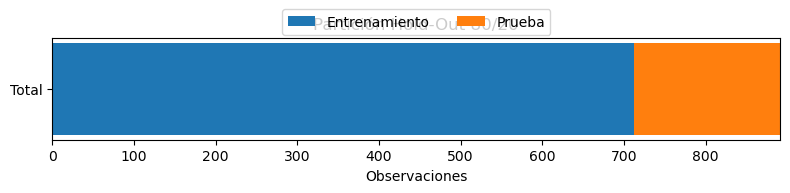

,Conjunto,N,Proporcion
0,Entrenamiento,712,0.799102
1,Prueba,179,0.200898


,Conjunto,Clase,Proporcion
0,Entrenamiento,0,0.616573
1,Entrenamiento,1,0.383427
2,Prueba,0,0.614525
3,Prueba,1,0.385475


,Metrica,Interpretacion
0,Accuracy,Proporción global de clasificaciones correctas.
1,Precision,"Entre las predicciones de supervivencia, propo..."
2,Recall,"Entre los sobrevivientes reales, proporción de..."
3,F1-score,Media armónica entre precision y recall para l...
4,ROC-AUC,Capacidad de ordenamiento entre clases a travé...
5,Average Precision,Resumen de la curva precision-recall para la c...


In [3]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

split = pd.DataFrame([
    {'Conjunto':'Entrenamiento', 'N':len(X_train), 'Proporcion':len(X_train)/len(X)},
    {'Conjunto':'Prueba', 'N':len(X_test), 'Proporcion':len(X_test)/len(X)},
])
split.to_csv(OUT_DIR/'06_dimensiones_split.csv', index=False)

balance = []
for nombre, yy in [('Entrenamiento', y_train), ('Prueba', y_test)]:
    vc = yy.value_counts(normalize=True).sort_index()
    for clase, prop in vc.items():
        balance.append({'Conjunto':nombre, 'Clase':int(clase), 'Proporcion':float(prop)})
balance = pd.DataFrame(balance)
balance.to_csv(OUT_DIR/'07_balance_train_test.csv', index=False)

criterios = pd.DataFrame([
    {'Metrica':'Accuracy', 'Interpretacion':'Proporción global de clasificaciones correctas.'},
    {'Metrica':'Precision', 'Interpretacion':'Entre las predicciones de supervivencia, proporción que realmente sobrevivió.'},
    {'Metrica':'Recall', 'Interpretacion':'Entre los sobrevivientes reales, proporción detectada por el modelo.'},
    {'Metrica':'F1-score', 'Interpretacion':'Media armónica entre precision y recall para la clase positiva.'},
    {'Metrica':'ROC-AUC', 'Interpretacion':'Capacidad de ordenamiento entre clases a través de todos los umbrales.'},
    {'Metrica':'Average Precision', 'Interpretacion':'Resumen de la curva precision-recall para la clase positiva.'},
])
criterios.to_csv(OUT_DIR/'08_criterios_metricas.csv', index=False)

fig, ax = plt.subplots(figsize=(8.0,2.3))
ax.barh(['Total'], [len(X_train)], label='Entrenamiento')
ax.barh(['Total'], [len(X_test)], left=[len(X_train)], label='Prueba')
ax.set_xlim(0,len(X)); ax.set_xlabel('Observaciones'); ax.set_title('Partición Hold-Out 80/20')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5,1.35))
fig.tight_layout(); fig.savefig(FIG_DIR/'03_particion_train_test.png', dpi=180, bbox_inches='tight'); plt.show()

display(split)
display(balance)
display(criterios)

## 3. Construcción de pipelines y evaluación Hold-Out de modelos supervisados

Para evitar filtración de información, cada modelo se encapsula con su preprocesamiento. Los modelos sensibles a escala (KNN, SVM y MLP) incorporan `StandardScaler` sobre variables numéricas. El árbol y GaussianNB utilizan imputación y codificación sin escalamiento numérico. Todos los transformadores se ajustan únicamente con el conjunto de entrenamiento.

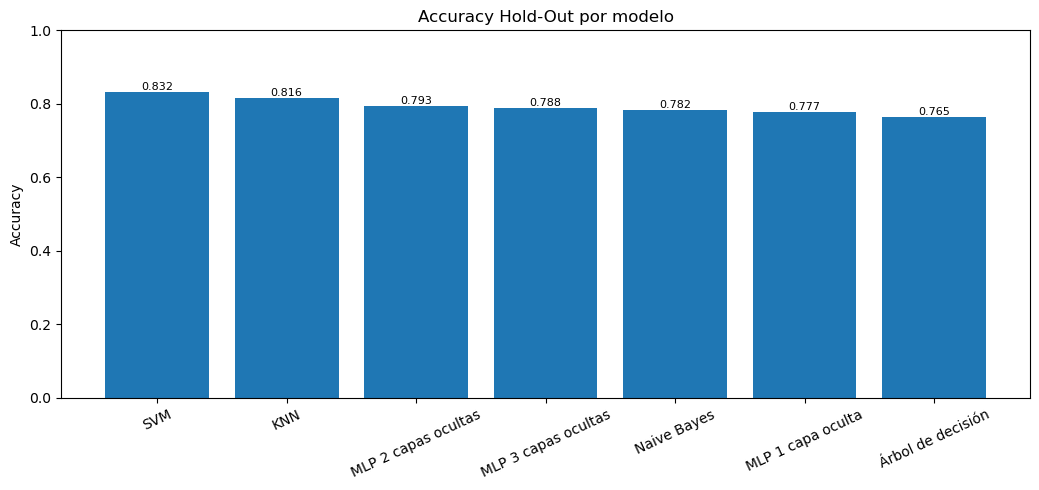

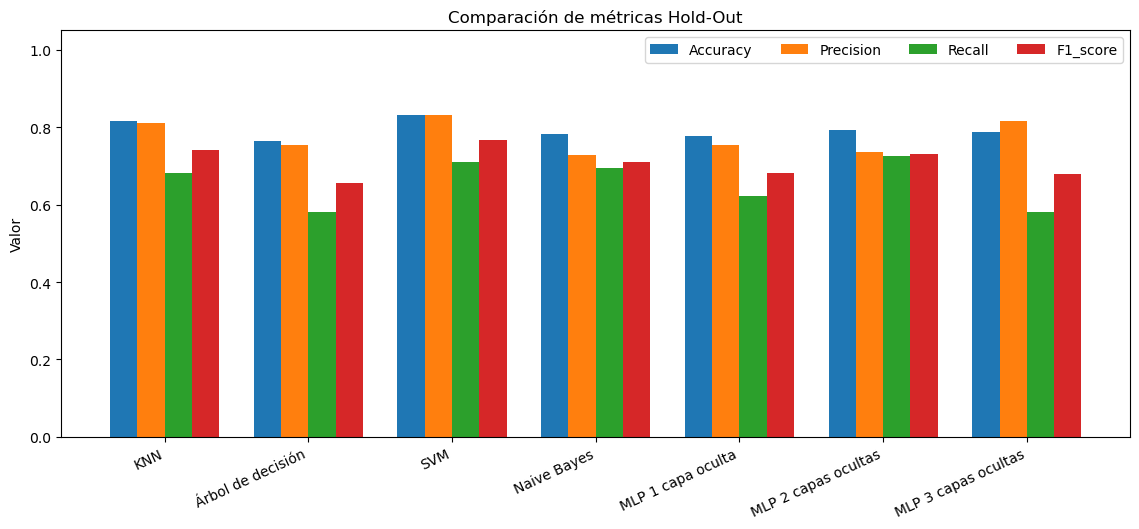

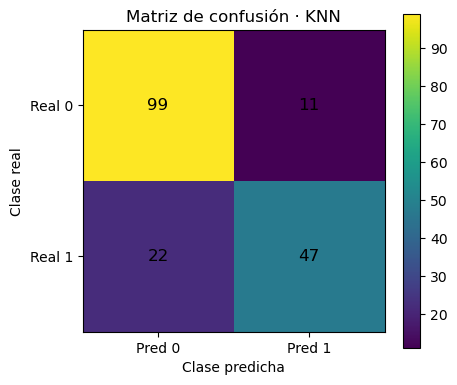

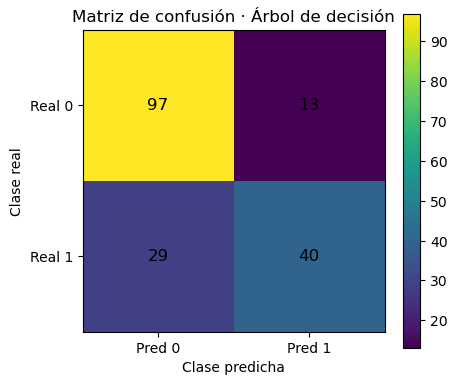

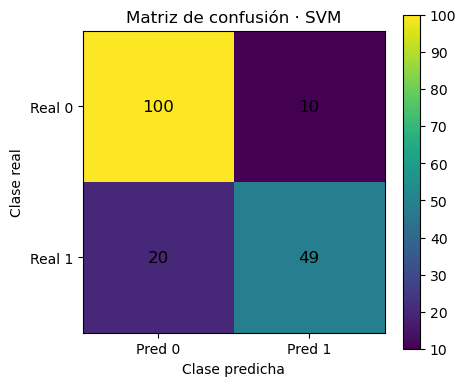

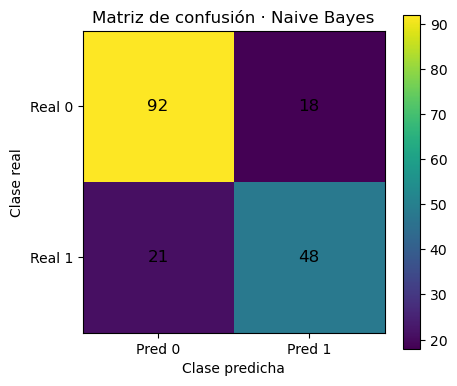

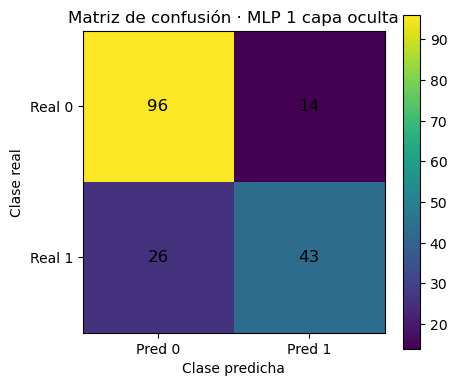

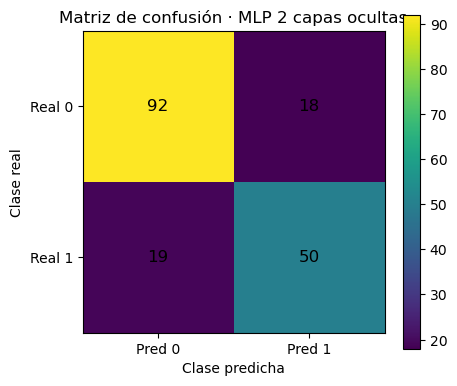

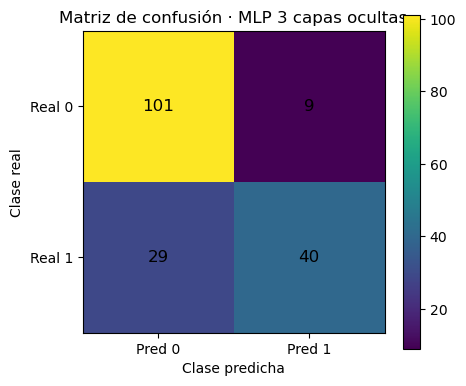

,Modelo,N_test,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,FPR,FNR,ROC_AUC,Average_Precision,TN,FP,FN,TP,Tiempo_ajuste_segundos
0,KNN,179,0.815642,0.810345,0.681159,0.740157,0.790580,0.900000,0.100000,0.318841,0.835310,0.744329,99,11,22,47,0.016454
1,Árbol de decisión,179,0.765363,0.754717,0.579710,0.655738,0.730764,0.881818,0.118182,0.420290,0.797101,0.763641,97,13,29,40,0.012362
2,SVM,179,0.832402,0.830508,0.710145,0.765625,0.809618,0.909091,0.090909,0.289855,0.833729,0.791283,100,10,20,49,0.025648
3,Naive Bayes,179,0.782123,0.727273,0.695652,0.711111,0.766008,0.836364,0.163636,0.304348,0.808037,0.713726,92,18,21,48,0.081176
4,MLP 1 capa oculta,179,0.776536,0.754386,0.623188,0.682540,0.747958,0.872727,0.127273,0.376812,0.835968,0.755664,96,14,26,43,0.262739
5,MLP 2 capas ocultas,179,0.793296,0.735294,0.724638,0.729927,0.780501,0.836364,0.163636,0.275362,0.852174,0.789082,92,18,19,50,0.304546
6,MLP 3 capas ocultas,179,0.787709,0.816327,0.579710,0.677966,0.748946,0.918182,0.081818,0.420290,0.837022,0.783233,101,9,29,40,0.294511


,Ranking_F1,Modelo,Accuracy,Precision,Recall,F1_score,ROC_AUC
0,1,SVM,0.832402,0.830508,0.710145,0.765625,0.833729
1,2,KNN,0.815642,0.810345,0.681159,0.740157,0.835310
2,3,MLP 2 capas ocultas,0.793296,0.735294,0.724638,0.729927,0.852174
3,4,Naive Bayes,0.782123,0.727273,0.695652,0.711111,0.808037
4,5,MLP 1 capa oculta,0.776536,0.754386,0.623188,0.682540,0.835968
5,6,MLP 3 capas ocultas,0.787709,0.816327,0.579710,0.677966,0.837022
6,7,Árbol de decisión,0.765363,0.754717,0.579710,0.655738,0.797101


In [4]:
def construir_preprocesador(escalar_numericas: bool) -> ColumnTransformer:
    pasos_num = [('imputer', SimpleImputer(strategy='median'))]
    if escalar_numericas:
        pasos_num.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(pasos_num)
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUM_FEATURES),
        ('cat', cat_pipe, CAT_FEATURES),
    ], remainder='drop', verbose_feature_names_out=False)


def construir_pipeline(nombre: str) -> Pipeline:
    if nombre == 'KNN':
        modelo = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
        escalar = True
    elif nombre == 'Árbol de decisión':
        modelo = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=RANDOM_STATE)
        escalar = False
    elif nombre == 'SVM':
        modelo = SVC(kernel='rbf', C=1, random_state=RANDOM_STATE)
        escalar = True
    elif nombre == 'Naive Bayes':
        modelo = GaussianNB()
        escalar = False
    elif nombre in architectures:
        modelo = MLPClassifier(hidden_layer_sizes=architectures[nombre], **common_mlp)
        escalar = True
    else:
        raise KeyError(nombre)
    return Pipeline([('preprocessor', construir_preprocesador(escalar)), ('model', modelo)])


def score_continuo(modelo, X_eval):
    if hasattr(modelo, 'predict_proba'):
        proba = modelo.predict_proba(X_eval)
        clases = list(modelo.classes_)
        return proba[:, clases.index(POS_LABEL)]
    if hasattr(modelo, 'decision_function'):
        return np.asarray(modelo.decision_function(X_eval), dtype=float)
    return None


def metricas_binarias(y_true, y_pred, score=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    row = {
        'Accuracy':accuracy_score(y_true,y_pred),
        'Precision':precision_score(y_true,y_pred,pos_label=POS_LABEL,zero_division=0),
        'Recall':recall_score(y_true,y_pred,pos_label=POS_LABEL,zero_division=0),
        'F1_score':f1_score(y_true,y_pred,pos_label=POS_LABEL,zero_division=0),
        'Balanced_accuracy':balanced_accuracy_score(y_true,y_pred),
        'Especificidad':tn/(tn+fp) if (tn+fp) else np.nan,
        'FPR':fp/(fp+tn) if (fp+tn) else np.nan,
        'FNR':fn/(fn+tp) if (fn+tp) else np.nan,
        'TN':int(tn),'FP':int(fp),'FN':int(fn),'TP':int(tp),
    }
    if score is not None:
        row['ROC_AUC'] = roc_auc_score(y_true, score)
        row['Average_Precision'] = average_precision_score(y_true, score)
    else:
        row['ROC_AUC'] = np.nan
        row['Average_Precision'] = np.nan
    return row, cm

nombres_modelos = ['KNN','Árbol de decisión','SVM','Naive Bayes', *architectures.keys()]
metric_rows=[]; matrices={}; fitted={}; pred_table=pd.DataFrame({'Indice_original':X_test.index, 'y_real':y_test.values})
warning_rows=[]

for nombre in nombres_modelos:
    pipe = construir_pipeline(nombre)
    inicio = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        pipe.fit(X_train, y_train)
    elapsed = time.perf_counter()-inicio
    y_pred = pipe.predict(X_test)
    score = score_continuo(pipe, X_test)
    row, cm = metricas_binarias(y_test, y_pred, score)
    row.update({'Modelo':nombre, 'N_test':len(y_test), 'Tiempo_ajuste_segundos':elapsed})
    metric_rows.append(row)
    matrices[nombre]=cm; fitted[nombre]=pipe
    pred_table[f'Pred_{nombre}']=y_pred
    if score is not None:
        pred_table[f'Score_{nombre}']=score
    for w in caught:
        warning_rows.append({'Modelo':nombre,'Categoria':w.category.__name__,'Mensaje':str(w.message)})

metricas = pd.DataFrame(metric_rows)[['Modelo','N_test','Accuracy','Precision','Recall','F1_score','Balanced_accuracy','Especificidad','FPR','FNR','ROC_AUC','Average_Precision','TN','FP','FN','TP','Tiempo_ajuste_segundos']]
metricas.to_csv(OUT_DIR/'09_metricas_holdout_modelos.csv', index=False)
pred_table.to_csv(OUT_DIR/'10_predicciones_holdout.csv', index=False)
pd.DataFrame(warning_rows, columns=['Modelo','Categoria','Mensaje']).to_csv(OUT_DIR/'11_advertencias_modelos.csv', index=False)

mat_long=[]; err_rows=[]
for nombre, cm in matrices.items():
    for i,real in enumerate([0,1]):
        for j,pred in enumerate([0,1]):
            mat_long.append({'Modelo':nombre,'Clase_real':real,'Clase_predicha':pred,'Frecuencia':int(cm[i,j])})
    yp = pred_table[f'Pred_{nombre}'].to_numpy()
    for idx, ytrue, yhat in zip(X_test.index, y_test.to_numpy(), yp):
        if int(ytrue)!=int(yhat):
            err_rows.append({'Modelo':nombre,'Indice_original':int(idx),'y_real':int(ytrue),'y_pred':int(yhat),'Tipo_error':'FP' if ytrue==0 else 'FN'})
pd.DataFrame(mat_long).to_csv(OUT_DIR/'12_matrices_confusion_holdout.csv', index=False)
pd.DataFrame(err_rows).to_csv(OUT_DIR/'13_errores_holdout.csv', index=False)

ranking = metricas.sort_values(['F1_score','Accuracy','Recall'], ascending=False).reset_index(drop=True)
ranking.insert(0,'Ranking_F1',np.arange(1,len(ranking)+1))
ranking.to_csv(OUT_DIR/'14_ranking_preliminar.csv', index=False)

# Control de continuidad de las tres arquitecturas MLP con los resultados archivados en Semana 3.
continuidad=[]
if METRICAS_MLP_S3_PATH.exists():
    hist = pd.read_csv(METRICAS_MLP_S3_PATH)
    for nombre in architectures:
        act = metricas.loc[metricas['Modelo']==nombre].iloc[0]
        ref = hist.loc[hist['Modelo']==nombre]
        if not ref.empty:
            ref=ref.iloc[0]
            for met in ['Accuracy','Precision','Recall','F1_score','Balanced_accuracy','Especificidad','TN','FP','FN','TP']:
                if met in ref.index:
                    a=float(act[met]); b=float(ref[met])
                    continuidad.append({'Modelo':nombre,'Metrica':met,'Formativa':a,'Semana3':b,'Diferencia_abs':abs(a-b),'Coincide':bool(np.isclose(a,b,rtol=0,atol=1e-12))})
continuidad=pd.DataFrame(continuidad)
continuidad.to_csv(OUT_DIR/'15_continuidad_mlp_semana3.csv', index=False)

# Figuras comparativas.
fig, ax = plt.subplots(figsize=(10.5,5.0))
ord_acc = metricas.sort_values('Accuracy',ascending=False)
bars=ax.bar(ord_acc['Modelo'],ord_acc['Accuracy'])
ax.set_ylim(0,1); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy Hold-Out por modelo'); ax.tick_params(axis='x',rotation=25)
for b,v in zip(bars,ord_acc['Accuracy']): ax.text(b.get_x()+b.get_width()/2,v,f'{v:.3f}',ha='center',va='bottom',fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR/'04_accuracy_modelos.png',dpi=180,bbox_inches='tight'); plt.show()

cols=['Accuracy','Precision','Recall','F1_score']
fig, ax=plt.subplots(figsize=(11.5,5.4)); x=np.arange(len(metricas)); w=0.19
for k,col in enumerate(cols):
    ax.bar(x+(k-1.5)*w,metricas[col],width=w,label=col)
ax.set_xticks(x); ax.set_xticklabels(metricas['Modelo'],rotation=25,ha='right'); ax.set_ylim(0,1.05); ax.set_ylabel('Valor'); ax.set_title('Comparación de métricas Hold-Out'); ax.legend(ncol=4)
fig.tight_layout(); fig.savefig(FIG_DIR/'05_metricas_modelos.png',dpi=180,bbox_inches='tight'); plt.show()

for num,nombre in enumerate(nombres_modelos, start=1):
    cm=matrices[nombre]
    fig,ax=plt.subplots(figsize=(4.8,4.1)); im=ax.imshow(cm)
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',fontsize=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['Real 0','Real 1']); ax.set_xlabel('Clase predicha'); ax.set_ylabel('Clase real'); ax.set_title(f'Matriz de confusión · {nombre}'); fig.colorbar(im,ax=ax)
    fig.tight_layout(); fig.savefig(FIG_DIR/f'{5+num:02d}_cm_{num:02d}.png',dpi=180,bbox_inches='tight'); plt.show()

display(metricas)
display(ranking[['Ranking_F1','Modelo','Accuracy','Precision','Recall','F1_score','ROC_AUC']])

## 4. Validación cruzada del MLP con una capa oculta

Se aplica **K-Fold estratificado de cinco particiones** (`StratifiedKFold`) exclusivamente sobre el conjunto de entrenamiento. Cada fold ajusta nuevamente imputación, codificación, escalamiento y MLP, evitando que el fold de validación participe en el aprendizaje de parámetros de preprocesamiento. Esta implementación conserva la exigencia de K-Fold y añade estratificación para mantener aproximadamente la proporción de clases en cada partición.

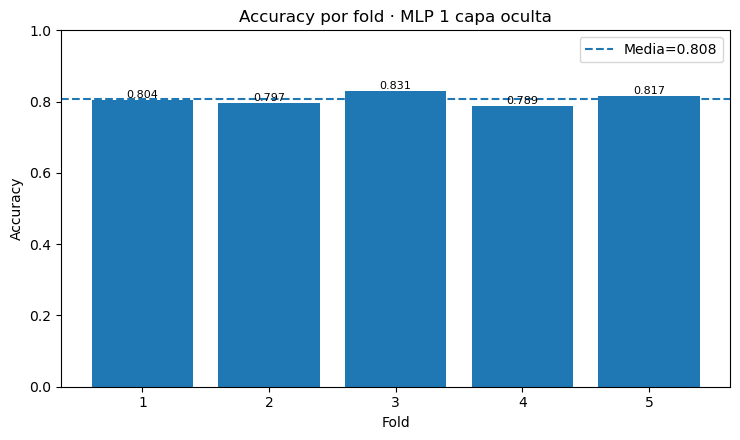

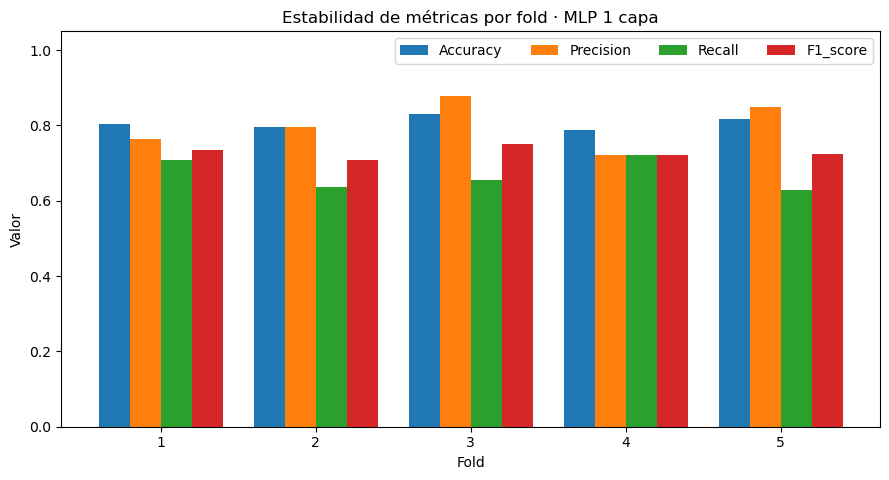

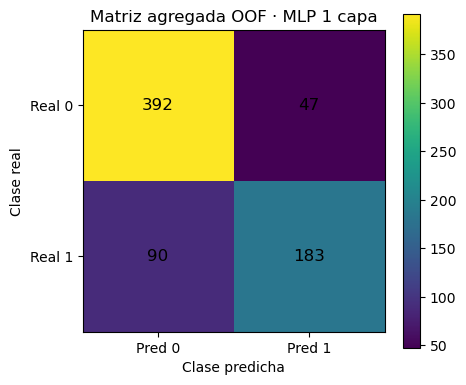

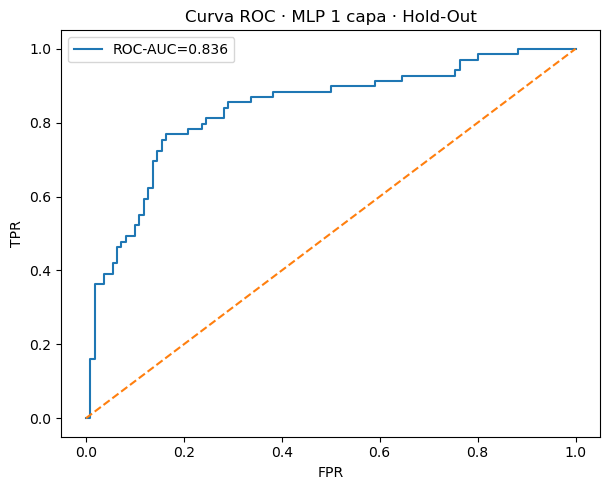

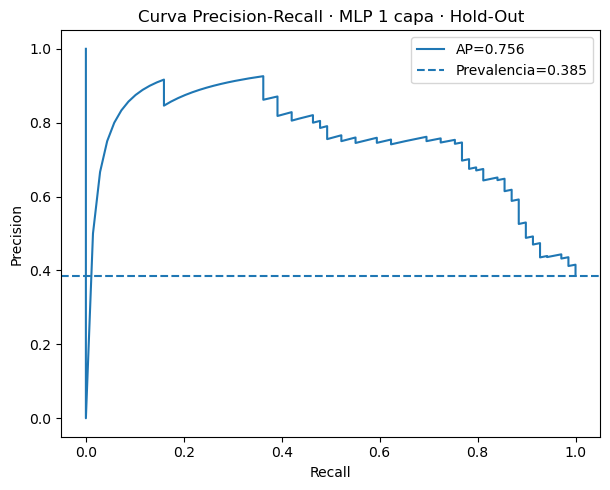

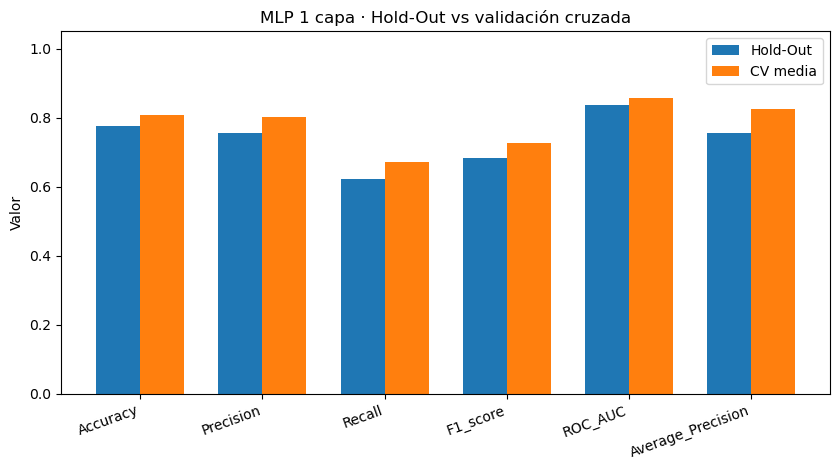

,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,FPR,FNR,TN,FP,FN,TP,ROC_AUC,Average_Precision,Fold,N_train_fold,N_validacion_fold,Tiempo_ajuste_segundos
0,0.804196,0.764706,0.709091,0.735849,0.786364,0.863636,0.136364,0.290909,76,12,16,39,0.865806,0.843170,1,569,143,0.163385
1,0.797203,0.795455,0.636364,0.707071,0.767045,0.897727,0.102273,0.363636,79,9,20,35,0.829236,0.811493,2,569,143,0.177527
2,0.830986,0.878049,0.654545,0.750000,0.798537,0.942529,0.057471,0.345455,82,5,19,36,0.873041,0.844224,3,570,142,0.145466
3,0.788732,0.722222,0.722222,0.722222,0.775884,0.829545,0.170455,0.277778,73,15,15,39,0.847959,0.817961,4,570,142,0.195354
4,0.816901,0.850000,0.629630,0.723404,0.780724,0.931818,0.068182,0.370370,82,6,20,34,0.869318,0.801786,5,570,142,0.212919


,Metrica,Media,Desv_estandar_muestral,Minimo,Maximo,Rango
0,Accuracy,0.807604,0.016652,0.788732,0.830986,0.042254
1,Precision,0.802086,0.063019,0.722222,0.878049,0.155827
2,Recall,0.670370,0.042587,0.629630,0.722222,0.092593
3,F1_score,0.727709,0.016107,0.707071,0.750000,0.042929
4,Balanced_accuracy,0.781711,0.011777,0.767045,0.798537,0.031492
5,Especificidad,0.893051,0.047093,0.829545,0.942529,0.112983
6,ROC_AUC,0.857072,0.018297,0.829236,0.873041,0.043805
7,Average_Precision,0.823727,0.019121,0.801786,0.844224,0.042438


,Fold,TN,FP,FN,TP
0,1,76,12,16,39
1,2,79,9,20,35
2,3,82,5,19,36
3,4,73,15,15,39
4,5,82,6,20,34


,Metrica,HoldOut,CV_media,Diferencia_HoldOut_menos_CV
0,Accuracy,0.776536,0.807604,-0.031067
1,Precision,0.754386,0.802086,-0.047700
2,Recall,0.623188,0.670370,-0.047182
3,F1_score,0.682540,0.727709,-0.045170
4,ROC_AUC,0.835968,0.857072,-0.021103
5,Average_Precision,0.755664,0.823727,-0.068063


,Tecnica,Numero_ajustes_MLP1,Costo_relativo,Uso,Tiempo_KFold_observado_segundos
0,Hold-Out,1,Bajo,Evaluación puntual sobre conjunto de prueba,NaN
1,K-Fold estratificado k=5,5,Medio,Estimación de estabilidad sobre entrenamiento,0.894651
2,Leave-One-Out,712,Alto,Referencia teórica de costo; no ejecutada,NaN


In [5]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
base_mlp1 = construir_pipeline('MLP 1 capa oculta')
cv_rows=[]; cv_mats=[]; oof_rows=[]; balance_folds=[]; warning_cv=[]
fit_times=[]

for fold,(tr_pos,va_pos) in enumerate(cv.split(X_train,y_train),start=1):
    Xtr=X_train.iloc[tr_pos]; Xva=X_train.iloc[va_pos]
    ytr=y_train.iloc[tr_pos]; yva=y_train.iloc[va_pos]
    pipe=clone(base_mlp1)
    inicio=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        pipe.fit(Xtr,ytr)
    elapsed=time.perf_counter()-inicio; fit_times.append(elapsed)
    yp=pipe.predict(Xva); score=score_continuo(pipe,Xva)
    row,cm=metricas_binarias(yva,yp,score)
    row.update({'Fold':fold,'N_train_fold':len(Xtr),'N_validacion_fold':len(Xva),'Tiempo_ajuste_segundos':elapsed})
    cv_rows.append(row); cv_mats.append(cm)
    balance_folds.append({'Fold':fold,'Prop_positiva_train':float(ytr.mean()),'Prop_positiva_validacion':float(yva.mean()),'N_train':len(ytr),'N_validacion':len(yva)})
    for idx,yt,yh,sc in zip(Xva.index,yva.to_numpy(),yp,np.asarray(score)):
        oof_rows.append({'Fold':fold,'Indice_original':int(idx),'y_real':int(yt),'y_pred':int(yh),'score':float(sc)})
    for w in caught:
        warning_cv.append({'Fold':fold,'Categoria':w.category.__name__,'Mensaje':str(w.message)})

cv_df=pd.DataFrame(cv_rows)
cv_df.to_csv(OUT_DIR/'16_cv_mlp1_metricas_por_fold.csv',index=False)
pd.DataFrame(balance_folds).to_csv(OUT_DIR/'17_cv_mlp1_balance_folds.csv',index=False)
oof=pd.DataFrame(oof_rows).sort_values('Indice_original').reset_index(drop=True)
oof.to_csv(OUT_DIR/'18_cv_mlp1_predicciones_oof.csv',index=False)
pd.DataFrame(warning_cv,columns=['Fold','Categoria','Mensaje']).to_csv(OUT_DIR/'19_cv_mlp1_advertencias.csv',index=False)

mat_rows=[]
for fold,cm in enumerate(cv_mats,start=1):
    tn,fp,fn,tp=cm.ravel(); mat_rows.append({'Fold':fold,'TN':int(tn),'FP':int(fp),'FN':int(fn),'TP':int(tp)})
mat_folds=pd.DataFrame(mat_rows); mat_folds.to_csv(OUT_DIR/'20_cv_mlp1_matrices_por_fold.csv',index=False)
cm_ag=confusion_matrix(oof['y_real'],oof['y_pred'],labels=[0,1])
pd.DataFrame(cm_ag,index=['Real_0','Real_1'],columns=['Pred_0','Pred_1']).to_csv(OUT_DIR/'21_cv_mlp1_matriz_agregada.csv')

metric_names=['Accuracy','Precision','Recall','F1_score','Balanced_accuracy','Especificidad','ROC_AUC','Average_Precision']
summary=[]
for m in metric_names:
    vals=cv_df[m].astype(float)
    summary.append({'Metrica':m,'Media':vals.mean(),'Desv_estandar_muestral':vals.std(ddof=1),'Minimo':vals.min(),'Maximo':vals.max(),'Rango':vals.max()-vals.min()})
resumen_cv=pd.DataFrame(summary); resumen_cv.to_csv(OUT_DIR/'22_cv_mlp1_resumen_estabilidad.csv',index=False)

# Métricas OOF agregadas, separadas del promedio por fold.
oof_metrics,_=metricas_binarias(oof['y_real'],oof['y_pred'],oof['score'])
pd.DataFrame([oof_metrics]).to_csv(OUT_DIR/'23_cv_mlp1_metricas_oof_agregadas.csv',index=False)

# Costo computacional y comparación conceptual.
costo=pd.DataFrame([
    {'Tecnica':'Hold-Out', 'Numero_ajustes_MLP1':1, 'Costo_relativo':'Bajo', 'Uso':'Evaluación puntual sobre conjunto de prueba'},
    {'Tecnica':'K-Fold estratificado k=5', 'Numero_ajustes_MLP1':N_SPLITS, 'Costo_relativo':'Medio', 'Uso':'Estimación de estabilidad sobre entrenamiento'},
    {'Tecnica':'Leave-One-Out', 'Numero_ajustes_MLP1':len(X_train), 'Costo_relativo':'Alto', 'Uso':'Referencia teórica de costo; no ejecutada'},
])
costo['Tiempo_KFold_observado_segundos']=np.nan
costo.loc[costo['Tecnica']=='K-Fold estratificado k=5','Tiempo_KFold_observado_segundos']=sum(fit_times)
costo.to_csv(OUT_DIR/'24_costo_validacion.csv',index=False)

# Comparación MLP1 Hold-Out vs media CV.
hold=metricas.loc[metricas['Modelo']=='MLP 1 capa oculta'].iloc[0]
comp=[]
for m in ['Accuracy','Precision','Recall','F1_score','ROC_AUC','Average_Precision']:
    cvmean=float(resumen_cv.loc[resumen_cv['Metrica']==m,'Media'].iloc[0])
    comp.append({'Metrica':m,'HoldOut':float(hold[m]),'CV_media':cvmean,'Diferencia_HoldOut_menos_CV':float(hold[m])-cvmean})
comp=pd.DataFrame(comp); comp.to_csv(OUT_DIR/'25_comparacion_mlp1_holdout_cv.csv',index=False)

# Controles de integridad de CV.
controles_cv=pd.DataFrame([
    {'Control':'OOF_cubre_todo_train', 'Valor':len(oof)==len(X_train)},
    {'Control':'Indices_OOF_unicos', 'Valor':oof['Indice_original'].nunique()==len(X_train)},
    {'Control':'OOF_disjunto_test', 'Valor':set(oof['Indice_original']).isdisjoint(set(X_test.index))},
    {'Control':'Matriz_agregada_suma_train', 'Valor':int(cm_ag.sum())==len(X_train)},
])
controles_cv.to_csv(OUT_DIR/'26_control_integridad_cv.csv',index=False)
if not controles_cv['Valor'].all():
    raise RuntimeError('Falló un control de integridad de la validación cruzada.')

# Figuras de validación.
fig,ax=plt.subplots(figsize=(7.5,4.5)); bars=ax.bar(cv_df['Fold'].astype(str),cv_df['Accuracy']); mean_acc=cv_df['Accuracy'].mean(); ax.axhline(mean_acc,linestyle='--',label=f'Media={mean_acc:.3f}'); ax.set_ylim(0,1); ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy por fold · MLP 1 capa oculta'); ax.legend()
for b,v in zip(bars,cv_df['Accuracy']): ax.text(b.get_x()+b.get_width()/2,v,f'{v:.3f}',ha='center',va='bottom',fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR/'13_cv_accuracy_por_fold.png',dpi=180,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(figsize=(9.0,4.9)); xs=np.arange(N_SPLITS); w=0.2
for k,m in enumerate(['Accuracy','Precision','Recall','F1_score']): ax.bar(xs+(k-1.5)*w,cv_df[m],width=w,label=m)
ax.set_xticks(xs); ax.set_xticklabels([str(i) for i in cv_df['Fold']]); ax.set_ylim(0,1.05); ax.set_xlabel('Fold'); ax.set_ylabel('Valor'); ax.set_title('Estabilidad de métricas por fold · MLP 1 capa'); ax.legend(ncol=4)
fig.tight_layout(); fig.savefig(FIG_DIR/'14_cv_estabilidad_metricas.png',dpi=180,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(figsize=(4.8,4.1)); im=ax.imshow(cm_ag)
for (i,j),v in np.ndenumerate(cm_ag): ax.text(j,i,str(v),ha='center',va='center',fontsize=12)
ax.set_xticks([0,1]);ax.set_yticks([0,1]);ax.set_xticklabels(['Pred 0','Pred 1']);ax.set_yticklabels(['Real 0','Real 1']);ax.set_xlabel('Clase predicha');ax.set_ylabel('Clase real');ax.set_title('Matriz agregada OOF · MLP 1 capa');fig.colorbar(im,ax=ax)
fig.tight_layout();fig.savefig(FIG_DIR/'15_cv_matriz_agregada.png',dpi=180,bbox_inches='tight');plt.show()

# ROC y Precision-Recall del MLP1 en Hold-Out.
mlp1=fitted['MLP 1 capa oculta']; score_hold=score_continuo(mlp1,X_test)
fpr,tpr,_=roc_curve(y_test,score_hold,pos_label=POS_LABEL)
fig,ax=plt.subplots(figsize=(6.2,5.0));ax.plot(fpr,tpr,label=f"ROC-AUC={roc_auc_score(y_test,score_hold):.3f}");ax.plot([0,1],[0,1],linestyle='--');ax.set(xlabel='FPR',ylabel='TPR',title='Curva ROC · MLP 1 capa · Hold-Out');ax.legend();fig.tight_layout();fig.savefig(FIG_DIR/'16_mlp1_roc_holdout.png',dpi=180,bbox_inches='tight');plt.show()

pr,rc,_=precision_recall_curve(y_test,score_hold,pos_label=POS_LABEL)
fig,ax=plt.subplots(figsize=(6.2,5.0));ax.plot(rc,pr,label=f"AP={average_precision_score(y_test,score_hold):.3f}");ax.axhline(y_test.mean(),linestyle='--',label=f'Prevalencia={y_test.mean():.3f}');ax.set(xlabel='Recall',ylabel='Precision',title='Curva Precision-Recall · MLP 1 capa · Hold-Out');ax.legend();fig.tight_layout();fig.savefig(FIG_DIR/'17_mlp1_precision_recall_holdout.png',dpi=180,bbox_inches='tight');plt.show()

fig,ax=plt.subplots(figsize=(8.5,4.8));xx=np.arange(len(comp));ww=0.36;ax.bar(xx-ww/2,comp['HoldOut'],width=ww,label='Hold-Out');ax.bar(xx+ww/2,comp['CV_media'],width=ww,label='CV media');ax.set_xticks(xx);ax.set_xticklabels(comp['Metrica'],rotation=20,ha='right');ax.set_ylim(0,1.05);ax.set_ylabel('Valor');ax.set_title('MLP 1 capa · Hold-Out vs validación cruzada');ax.legend();fig.tight_layout();fig.savefig(FIG_DIR/'18_mlp1_holdout_vs_cv.png',dpi=180,bbox_inches='tight');plt.show()

display(cv_df)
display(resumen_cv)
display(mat_folds)
display(comp)
display(costo)

## 5. Interpretación comparativa y justificación metodológica

La evidencia generada permite comparar desempeño puntual en Hold-Out y estabilidad del MLP de una capa oculta bajo validación cruzada. La selección preliminar no debe basarse únicamente en accuracy: precision, recall, F1-score, matriz de confusión, ROC-AUC, costo de falsos positivos/falsos negativos y variabilidad entre folds aportan información complementaria.

Para este tamaño de entrenamiento, K-Fold con cinco particiones representa un compromiso entre una única división Hold-Out y el costo de Leave-One-Out. El informe debe interpretar los valores obtenidos en la ejecución, evitando afirmar estabilidad uniforme si alguna métrica presenta variabilidad materialmente mayor que las restantes.

In [6]:
# Tabla de evidencia para la interpretación y la posterior redacción del informe.
resumen_decision = ranking[['Ranking_F1','Modelo','Accuracy','Precision','Recall','F1_score','ROC_AUC','Average_Precision','FP','FN']].copy()
resumen_decision.to_csv(OUT_DIR/'27_resumen_para_decision.csv',index=False)

display(resumen_decision)

,Ranking_F1,Modelo,Accuracy,Precision,Recall,F1_score,ROC_AUC,Average_Precision,FP,FN
0,1,SVM,0.832402,0.830508,0.710145,0.765625,0.833729,0.791283,10,20
1,2,KNN,0.815642,0.810345,0.681159,0.740157,0.835310,0.744329,11,22
2,3,MLP 2 capas ocultas,0.793296,0.735294,0.724638,0.729927,0.852174,0.789082,18,19
3,4,Naive Bayes,0.782123,0.727273,0.695652,0.711111,0.808037,0.713726,18,21
4,5,MLP 1 capa oculta,0.776536,0.754386,0.623188,0.682540,0.835968,0.755664,14,26
5,6,MLP 3 capas ocultas,0.787709,0.816327,0.579710,0.677966,0.837022,0.783233,9,29
6,7,Árbol de decisión,0.765363,0.754717,0.579710,0.655738,0.797101,0.763641,13,29


## 6. Trazabilidad de la rúbrica y control final

La última sección verifica la existencia de las evidencias necesarias para los criterios técnicos de la Formativa 4. Los criterios formales del PDF —portada, índice, formato institucional, ortografía, APA y anexos— se completan después de ejecutar el notebook y se construyen exclusivamente con los resultados reales de esta corrida.

In [7]:
trazabilidad = pd.DataFrame([
    {'Criterio':'C1 Descripción de modelos y dataset','Evidencia_notebook':'Secciones 1-2','Artefactos':'01_perfil_dataset.csv; 03_distribucion_clases.csv; 04_modelos_configuracion.csv'},
    {'Criterio':'C2 Preparación del proceso de evaluación','Evidencia_notebook':'Sección 2','Artefactos':'06_dimensiones_split.csv; 07_balance_train_test.csv; 08_criterios_metricas.csv'},
    {'Criterio':'C3 Evaluación de modelos supervisados','Evidencia_notebook':'Sección 3','Artefactos':'09_metricas_holdout_modelos.csv; 14_ranking_preliminar.csv'},
    {'Criterio':'C4 Matriz de confusión y métricas','Evidencia_notebook':'Sección 3','Artefactos':'09_metricas_holdout_modelos.csv; 12_matrices_confusion_holdout.csv; figuras 06-12'},
    {'Criterio':'C5 Validación cruzada MLP una capa','Evidencia_notebook':'Sección 4','Artefactos':'16_cv_mlp1_metricas_por_fold.csv; 22_cv_mlp1_resumen_estabilidad.csv; 21_cv_mlp1_matriz_agregada.csv'},
    {'Criterio':'C6 Interpretación comparativa','Evidencia_notebook':'Sección 5','Artefactos':'25_comparacion_mlp1_holdout_cv.csv; 27_resumen_para_decision.csv'},
    {'Criterio':'C7 Justificación metodológica','Evidencia_notebook':'Secciones 4-5','Artefactos':'24_costo_validacion.csv; 22_cv_mlp1_resumen_estabilidad.csv'},
    {'Criterio':'C8 Notebook y documentación','Evidencia_notebook':'Flujo completo y control final','Artefactos':'28_trazabilidad_rubrica.csv; 29_control_artefactos_requeridos.csv'},
    {'Criterio':'C10-C14 Criterios formales','Evidencia_notebook':'No sustituyen al informe PDF','Artefactos':'Se completan en el informe final con resultados de esta ejecución'},
])
trazabilidad.to_csv(OUT_DIR/'28_trazabilidad_rubrica.csv',index=False)

required_outputs = [
'00_versiones_entorno.csv','01_perfil_dataset.csv','02_valores_faltantes.csv','03_distribucion_clases.csv','04_modelos_configuracion.csv','05_control_configuracion_mlp_semana3.csv','06_dimensiones_split.csv','07_balance_train_test.csv','08_criterios_metricas.csv','09_metricas_holdout_modelos.csv','10_predicciones_holdout.csv','11_advertencias_modelos.csv','12_matrices_confusion_holdout.csv','13_errores_holdout.csv','14_ranking_preliminar.csv','15_continuidad_mlp_semana3.csv','16_cv_mlp1_metricas_por_fold.csv','17_cv_mlp1_balance_folds.csv','18_cv_mlp1_predicciones_oof.csv','19_cv_mlp1_advertencias.csv','20_cv_mlp1_matrices_por_fold.csv','21_cv_mlp1_matriz_agregada.csv','22_cv_mlp1_resumen_estabilidad.csv','23_cv_mlp1_metricas_oof_agregadas.csv','24_costo_validacion.csv','25_comparacion_mlp1_holdout_cv.csv','26_control_integridad_cv.csv','27_resumen_para_decision.csv','28_trazabilidad_rubrica.csv']
required_figures=['01_distribucion_clases.png','02_valores_faltantes.png','03_particion_train_test.png','04_accuracy_modelos.png','05_metricas_modelos.png']+[f'{i:02d}_cm_{i-5:02d}.png' for i in range(6,13)]+['13_cv_accuracy_por_fold.png','14_cv_estabilidad_metricas.png','15_cv_matriz_agregada.png','16_mlp1_roc_holdout.png','17_mlp1_precision_recall_holdout.png','18_mlp1_holdout_vs_cv.png']

checks=[]
for name in required_outputs:
    p=OUT_DIR/name; checks.append({'Tipo':'output','Archivo':name,'Existe':p.exists(),'Bytes':p.stat().st_size if p.exists() else 0})
for name in required_figures:
    p=FIG_DIR/name; checks.append({'Tipo':'figure','Archivo':name,'Existe':p.exists(),'Bytes':p.stat().st_size if p.exists() else 0})
control=pd.DataFrame(checks); control.to_csv(OUT_DIR/'29_control_artefactos_requeridos.csv',index=False)

faltantes_req=control.loc[~control['Existe'],'Archivo'].tolist()
if faltantes_req:
    raise RuntimeError('Faltan artefactos requeridos: '+', '.join(faltantes_req))

# Manifiesto de integridad de los artefactos generados.
def sha_file(p): return hashlib.sha256(p.read_bytes()).hexdigest()
man=[]
for d,tipo in [(OUT_DIR,'output'),(FIG_DIR,'figure')]:
    for p in sorted(d.iterdir()):
        if p.is_file() and p.name not in ['30_manifiesto_artefactos.csv','31_metadata_ejecucion.json']:
            man.append({'Tipo':tipo,'Archivo':p.name,'Bytes':p.stat().st_size,'SHA256':sha_file(p)})
man=pd.DataFrame(man); man.to_csv(OUT_DIR/'30_manifiesto_artefactos.csv',index=False)

metadata={
    'actividad':'Evaluación Formativa 4 · Fase 4',
    'dataset':'Semana3/data/titanic.csv',
    'target':TARGET,'positive_class':POS_LABEL,
    'random_state':RANDOM_STATE,'test_size':TEST_SIZE,
    'cv':'StratifiedKFold','n_splits':N_SPLITS,
    'modelos':nombres_modelos,
    'timestamp_local':pd.Timestamp.now().isoformat(),
}
(OUT_DIR/'31_metadata_ejecucion.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')

# Control numérico mínimo.
if not (metricas[['TN','FP','FN','TP']].sum(axis=1) == len(y_test)).all():
    raise RuntimeError('Una o más matrices Hold-Out no suman el tamaño del conjunto de prueba.')
if int(cm_ag.sum()) != len(y_train):
    raise RuntimeError('La matriz CV agregada no suma el tamaño del conjunto de entrenamiento.')

print('Control final de consistencia: OK')
print('Validación cruzada MLP 1 capa: OK')
print('Artefactos requeridos: OK')
display(trazabilidad)
display(control)

Control final de consistencia: OK
Validación cruzada MLP 1 capa: OK
Artefactos requeridos: OK


,Criterio,Evidencia_notebook,Artefactos
0,C1 Descripción de modelos y dataset,Secciones 1-2,01_perfil_dataset.csv; 03_distribucion_clases....
1,C2 Preparación del proceso de evaluación,Sección 2,06_dimensiones_split.csv; 07_balance_train_tes...
2,C3 Evaluación de modelos supervisados,Sección 3,09_metricas_holdout_modelos.csv; 14_ranking_pr...
3,C4 Matriz de confusión y métricas,Sección 3,09_metricas_holdout_modelos.csv; 12_matrices_c...
4,C5 Validación cruzada MLP una capa,Sección 4,16_cv_mlp1_metricas_por_fold.csv; 22_cv_mlp1_r...
5,C6 Interpretación comparativa,Sección 5,25_comparacion_mlp1_holdout_cv.csv; 27_resumen...
6,C7 Justificación metodológica,Secciones 4-5,24_costo_validacion.csv; 22_cv_mlp1_resumen_es...
7,C8 Notebook y documentación,Flujo completo y control final,28_trazabilidad_rubrica.csv; 29_control_artefa...
8,C10-C14 Criterios formales,No sustituyen al informe PDF,Se completan en el informe final con resultado...


,Tipo,Archivo,Existe,Bytes
0,output,00_versiones_entorno.csv,True,101
1,output,01_perfil_dataset.csv,True,229
2,output,02_valores_faltantes.csv,True,104
3,output,03_distribucion_clases.csv,True,79
4,output,04_modelos_configuracion.csv,True,495
5,output,05_control_configuracion_mlp_semana3.csv,True,260
6,output,06_dimensiones_split.csv,True,93
7,output,07_balance_train_test.csv,True,158
8,output,08_criterios_metricas.csv,True,492
9,output,09_metricas_holdout_modelos.csv,True,1808
